# Life expectancy
Computes life expectancy from year-precise birth and death dates across history and by occupation.

In [1]:
import tempfile
import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

SEED = 42
np.random.seed(SEED)

DB_PATH = '../data/cultura/humans_clean_v2.duckdb'
CV_DB_PATH = '../data/similar_databases/cross_verified.duckdb'
YEAR_OR_FINER = ('day', 'month', 'year')

pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(80)

COLORS = {'dot': '#b9bfc8', 'line': '#d9694f', 'grid': '#ececec'}
OCCUPATION_COLORS = {
    'Culture': '#5b8fc7',
    'Discovery/Science': '#6fb07f',
    'Leadership': '#e39b5b',
    'Sports/Games': '#a58cc7',
}
FIGSIZE = (13, 5.5)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': FIGSIZE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.formatter.useoffset': False,
})

## External data — Cross-Verified occupations

In [2]:
cv_con = duckdb.connect(CV_DB_PATH, read_only=True)
cv_occupations = cv_con.sql("""
    SELECT
        wikidata_code AS qid,
        level1_main_occ
    FROM individuals
    WHERE wikidata_code IS NOT NULL
      AND level1_main_occ IS NOT NULL
""").pl()
cv_con.close()

assert cv_occupations['qid'].n_unique() == cv_occupations.height
print('shape:', cv_occupations.shape)
cv_occupations.head()

shape: (2291817, 2)


qid,level1_main_occ
str,str
"""Q1000002""","""Culture"""
"""Q1000005""","""Culture"""
"""Q1000006""","""Culture"""
"""Q1000015""","""Culture"""
"""Q1000023""","""Leadership"""


## Load data
### Birth–death pairs

In [3]:
con = duckdb.connect(DB_PATH, read_only=True)
con.sql(f"SET memory_limit='4GB'; SET threads=6; SET temp_directory='{tempfile.mkdtemp()}';")
con.sql("CREATE TEMP MACRO from_llm(d) AS coalesce(d.field_provenance['year'].ai_answer.prompt_id = 'wikipedia_dates', false)")
con.sql("CREATE TEMP MACRO iso_month(d) AS CAST(regexp_extract(d.iso, '^-?\\d+-(\\d+)', 1) AS INT)")
con.sql("CREATE TEMP MACRO iso_day(d) AS CAST(regexp_extract(d.iso, '^-?\\d+-\\d+-(\\d+)', 1) AS INT)")
con.sql("CREATE TEMP MACRO frac_year(d) AS d.year + (30 * (iso_month(d) - 1) + iso_day(d) - 1) / 365.0")

birth_death_pairs = con.sql("""
    SELECT
        entity.qid                                               AS qid,
        birth_date[1].year                                       AS birth_year,
        frac_year(death_date[1]) - frac_year(birth_date[1])      AS life_expectancy_years,
        from_llm(birth_date[1]) OR from_llm(death_date[1])       AS from_llm
    FROM individual
    WHERE list_contains($year_or_finer, birth_date[1].precision)
      AND list_contains($year_or_finer, death_date[1].precision)
""", params={'year_or_finer': list(YEAR_OR_FINER)}).pl()
con.close()

assert birth_death_pairs['qid'].n_unique() == birth_death_pairs.height
print('shape:', birth_death_pairs.shape)
print(f"pairs using an LLM (Wikipedia) date: {birth_death_pairs['from_llm'].sum():,}")
birth_death_pairs.head()

shape: (3117584, 4)
pairs using an LLM (Wikipedia) date: 464


qid,birth_year,life_expectancy_years,from_llm
str,i64,f64,bool
"""Q106577762""",1778,55.0,false
"""Q106577976""",1996,24.558904,false
"""Q106578020""",1911,81.424658,false
"""Q106578135""",1906,39.043836,false
"""Q106580116""",1907,37.167123,false


## Stated dates only

## Life expectancy (0–110 years)

In [4]:
LIFE_EXPECTANCY_MIN = 0
LIFE_EXPECTANCY_MAX = 110

life_expectancy = birth_death_pairs.drop_nulls('life_expectancy_years').filter(
    pl.col('life_expectancy_years').is_between(LIFE_EXPECTANCY_MIN, LIFE_EXPECTANCY_MAX)
)
print(f'rows: {birth_death_pairs.height:,} -> {life_expectancy.height:,} '
      f'(dropped {birth_death_pairs.height - life_expectancy.height:,} outside [0, 110] or unparsable)')
life_expectancy.head()

rows: 3,117,584 -> 3,114,944 (dropped 2,640 outside [0, 110] or unparsable)


qid,birth_year,life_expectancy_years,from_llm
str,i64,f64,bool
"""Q106577762""",1778,55.0,false
"""Q106577976""",1996,24.558904,false
"""Q106578020""",1911,81.424658,false
"""Q106578135""",1906,39.043836,false
"""Q106580116""",1907,37.167123,false


## Median per 50-year bin

In [5]:
BIN_WIDTH = 50
MIN_BIN_N = 50
MAX_BIRTH_YEAR = 1900
X_MIN = -800

def add_birth_bin(df):
    return df.filter(pl.col('birth_year') < MAX_BIRTH_YEAR).with_columns(
        (pl.col('birth_year') // BIN_WIDTH * BIN_WIDTH).alias('birth_bin')
    )

life_expectancy_by_bin = (
    add_birth_bin(life_expectancy)
    .group_by('birth_bin')
    .agg(pl.col('life_expectancy_years').median().alias('median_life_expectancy'),
         pl.col('life_expectancy_years').mean().alias('mean_life_expectancy'),
         pl.len().alias('n'))
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('birth_bin')
)
print('shape:', life_expectancy_by_bin.shape)
life_expectancy_by_bin.filter(pl.col('birth_bin') >= X_MIN).head()

shape: (48, 4)


birth_bin,median_life_expectancy,mean_life_expectancy,n
i64,f64,f64,u32
-500,66.0,64.449129,59
-450,57.0,60.019569,63
-400,60.0,60.123709,104
-350,60.0,57.041067,95
-300,55.0,55.19324,92


### Median by occupation

In [6]:
SHOW_OCCUPATIONS = list(OCCUPATION_COLORS)

life_expectancy_with_occupation = (
    add_birth_bin(life_expectancy)
    .join(cv_occupations, on='qid', how='inner')
    .filter(pl.col('level1_main_occ').is_in(SHOW_OCCUPATIONS))
)
life_expectancy_by_bin_occupation = (
    life_expectancy_with_occupation
    .group_by('level1_main_occ', 'birth_bin')
    .agg(pl.col('life_expectancy_years').median().alias('median_life_expectancy'), pl.len().alias('n'))
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('level1_main_occ', 'birth_bin')
)
print(f'individuals matched to a CV occupation: {life_expectancy_with_occupation.height:,}')
print('per-bin shape:', life_expectancy_by_bin_occupation.shape)
life_expectancy_by_bin_occupation.head()

individuals matched to a CV occupation: 549,225
per-bin shape: (89, 4)


level1_main_occ,birth_bin,median_life_expectancy,n
str,i64,f64,u32
"""Culture""",700,67.0,51
"""Culture""",750,62.731507,55
"""Culture""",900,62.152055,64
"""Culture""",950,62.828767,64
"""Culture""",1000,64.621918,69


## Figures

In [7]:
TICKS = np.arange(-800, 1901, 200)
TICK_LABELS = [f'{abs(c)} BC' if c < 0 else str(c) for c in TICKS]

def style_axis(ax):
    ax.set_xticks(TICKS)
    ax.set_xticklabels(TICK_LABELS)
    ax.set_xlim(X_MIN, MAX_BIRTH_YEAR + 10)
    ax.set_ylim(0, 110)
    ax.set_xlabel('Birth year')
    ax.grid(axis='y', color=COLORS['grid'], lw=0.8)

### Fig 1 — Life expectancy through history

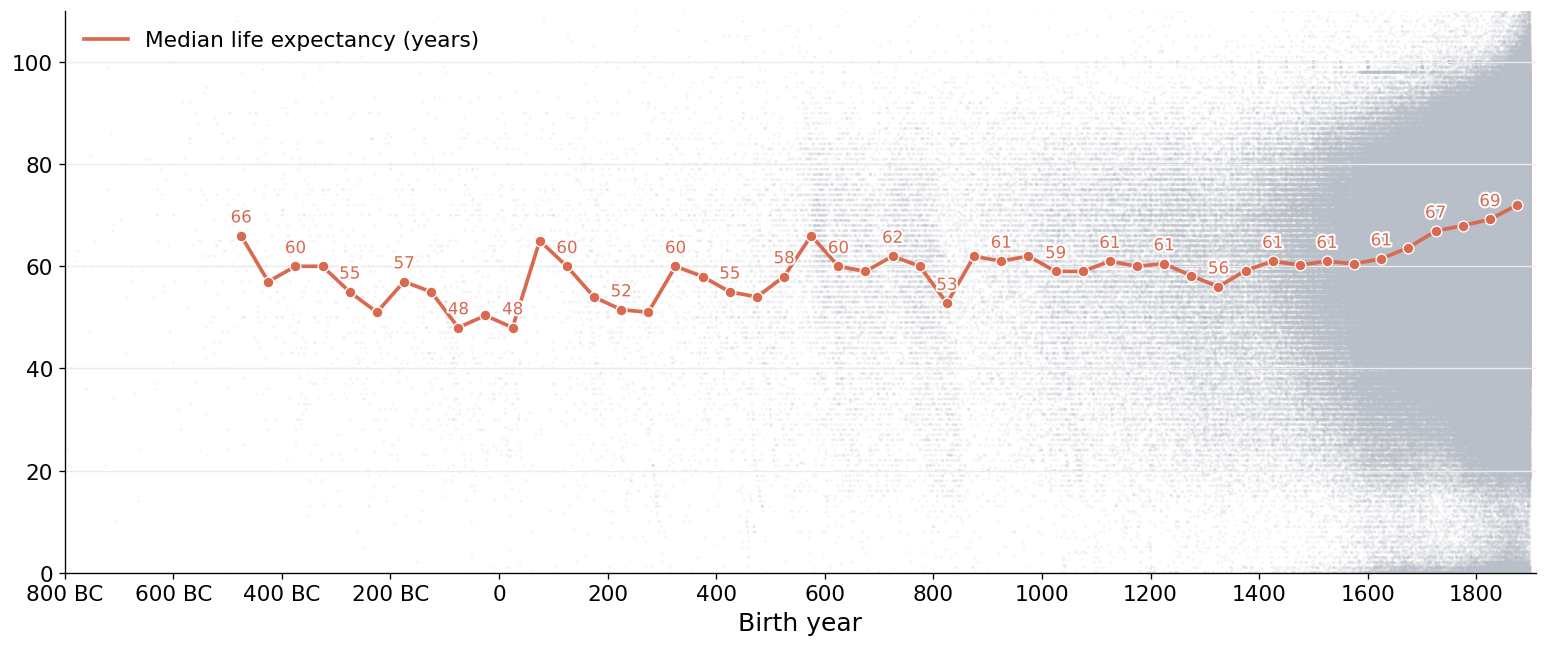

In [8]:
dots = add_birth_bin(life_expectancy).filter(pl.col('birth_year') >= X_MIN)
bins = life_expectancy_by_bin.filter(pl.col('birth_bin') >= X_MIN)
bin_x = bins['birth_bin'].to_numpy() + BIN_WIDTH / 2
bin_median = bins['median_life_expectancy'].to_numpy()

fig, ax = plt.subplots()
ax.scatter(dots['birth_year'], dots['life_expectancy_years'], s=3, color=COLORS['dot'],
           alpha=0.14, edgecolor='none', rasterized=True)
ax.plot(bin_x, bin_median, color=COLORS['line'], lw=2.2, label='Median life expectancy (years)')
ax.scatter(bin_x, bin_median, s=42, color=COLORS['line'], edgecolor='white', lw=0.8, zorder=3)
for i, (x, y) in enumerate(zip(bin_x, bin_median)):
    if i % 2 == 0:
        ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center',
                    fontsize=10, color=COLORS['line'],
                    path_effects=[patheffects.withStroke(linewidth=2.5, foreground='white')])
style_axis(ax)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

### Fig 2 — Life expectancy by occupation

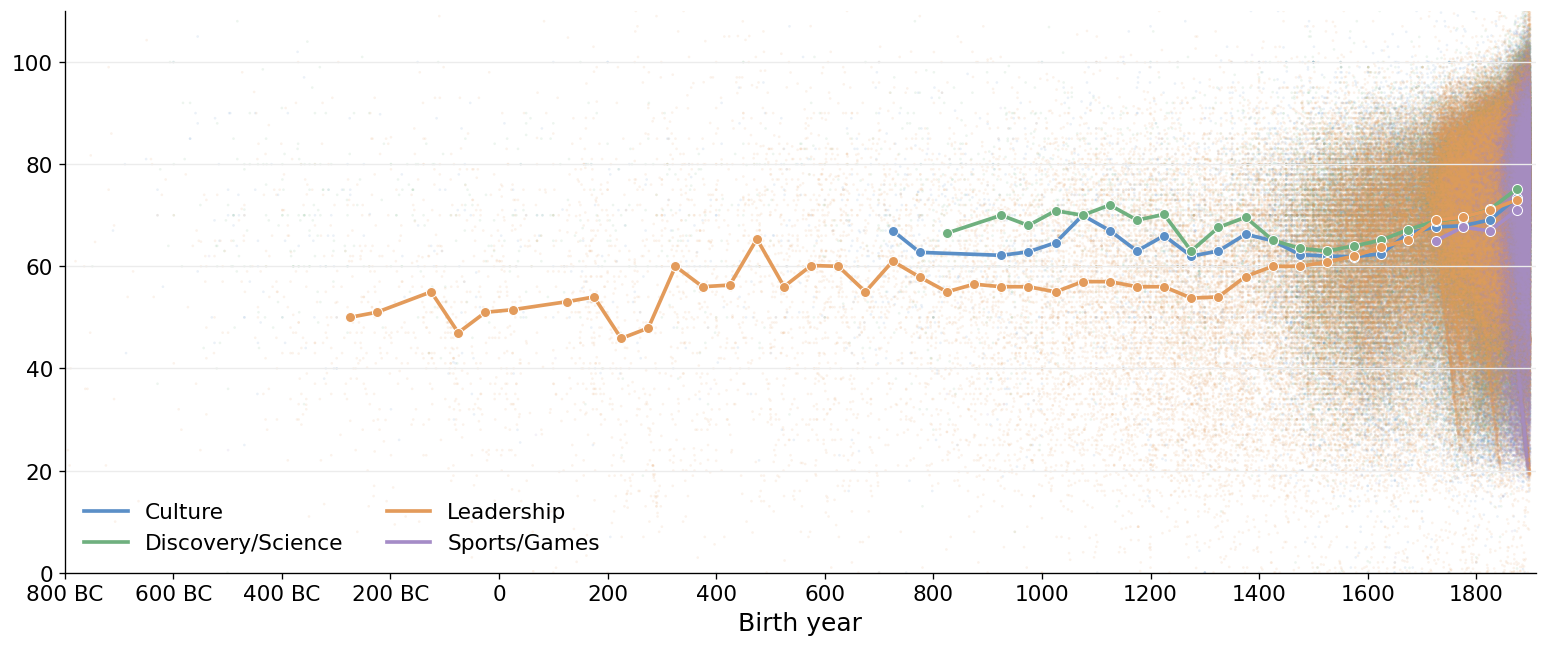

In [9]:
fig, ax = plt.subplots()
for occupation, color in OCCUPATION_COLORS.items():
    people = life_expectancy_with_occupation.filter(
        (pl.col('level1_main_occ') == occupation) & (pl.col('birth_year') >= X_MIN))
    ax.scatter(people['birth_year'], people['life_expectancy_years'], s=2.5, color=color,
               alpha=0.12, edgecolor='none', rasterized=True)

for occupation, color in OCCUPATION_COLORS.items():
    b = life_expectancy_by_bin_occupation.filter(
        (pl.col('level1_main_occ') == occupation) & (pl.col('birth_bin') >= X_MIN))
    x = b['birth_bin'].to_numpy() + BIN_WIDTH / 2
    ax.plot(x, b['median_life_expectancy'], color=color, lw=2.2, label=occupation)
    ax.scatter(x, b['median_life_expectancy'], s=36, color=color, edgecolor='white', lw=0.6, zorder=3)

style_axis(ax)
ax.legend(frameon=False, loc='lower left', ncol=2)
plt.tight_layout()
plt.show()